# Interactive attention visualization — Stable Diffusion 1.5

This notebook generates one image with SD 1.5 and lets you explore, interactively:

1. **Cross-attention** — pick a text token from the dropdown to see which image
   regions depended on that word.
2. **Self-attention** — pick an image region (sliders, or click if `ipympl` is
   installed) to see which other regions that patch attended to.

All heavy lifting lives in the `attnviz` package; this notebook is just the UI.


## 1. Setup & generate

Run once. The first run downloads ~5 GB of weights.


In [12]:
%load_ext autoreload
%autoreload 2
import sys, os
sys.path.insert(0, os.path.abspath('..'))  # so `import attnviz` works from notebooks/

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

from attnviz import (
    Config, DeviceResolver, PipelineLoader, Generator,
    CrossAttentionVisualizer, SelfAttentionVisualizer,
)

In [ ]:
# --- edit these ---
PROMPT = 'a cat sitting on a red sofa'
STEPS  = 5        # lower (e.g. 15) if running on CPU
SIZE   = 512
SEED   = 0

config   = Config(num_inference_steps=STEPS, image_size=SIZE, seed=SEED)
resolver = DeviceResolver(config.device, config.dtype)
print('Device:', resolver)

loader = PipelineLoader(config, resolver)
loader.load()
print('Model loaded.')

Device: DeviceResolver(device='mps', dtype=torch.float32)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Model loaded.


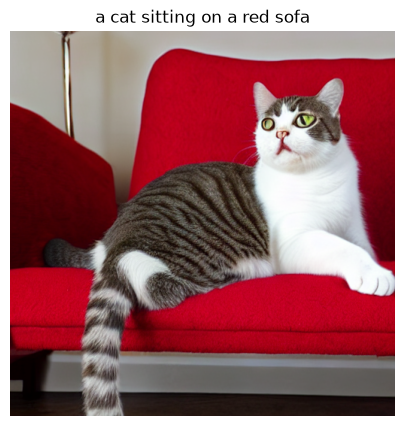

Tokens: ['<|startoftext|>', 'a', 'cat', 'sitting', 'on', 'a', 'red', 'sofa', '<|endoftext|>']


In [8]:
generator = Generator(config, loader)
result = generator.generate(PROMPT)

plt.figure(figsize=(5,5))
plt.imshow(result.image); plt.axis('off'); plt.title(PROMPT); plt.show()
print('Tokens:', result.tokens)

## 2. Cross-attention: text token → image regions

Pick a word. The heatmap shows where in the image that token was attended to.


In [ ]:
import io

cross = CrossAttentionVisualizer(result)
# include the [start] and [end] marker tokens, not just words
options = [(f'{i}: {cross.display_label(i)}', i) for i in cross.displayable_token_indices()]
token_dropdown = widgets.Dropdown(options=options, description='token:')
alpha_slider = widgets.FloatSlider(value=0.6, min=0.0, max=1.0, step=0.05, description='overlay')
# layer selector: None = average over layers, otherwise one UNet layer
layer_options = [('All layers (avg)', None)] + [(L['label'], L['name']) for L in cross.available_layers()]
layer_dropdown = widgets.Dropdown(options=layer_options, description='layer:')
# values: pre-softmax scores (better for text->image) vs post-softmax probs
source_dropdown = widgets.Dropdown(options=[('Pre-softmax scores', 'score'), ('Post-softmax probs', 'prob')], description='values:')
cross_img = widgets.Image(format='png')

def render_cross(change=None):
    fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
    ax[0].imshow(result.image); ax[0].set_title('image'); ax[0].axis('off')
    ax[1].imshow(cross.overlay(token_dropdown.value, alpha=alpha_slider.value,
                               layer=layer_dropdown.value, source=source_dropdown.value))
    ax[1].set_title(f"cross-attn: '{cross.display_label(token_dropdown.value)}'"); ax[1].axis('off')
    fig.tight_layout()
    buf = io.BytesIO(); fig.savefig(buf, format='png', dpi=110, bbox_inches='tight')
    plt.close(fig)
    cross_img.value = buf.getvalue()

for w in (token_dropdown, alpha_slider, layer_dropdown, source_dropdown):
    w.observe(render_cross, names='value')
render_cross()
display(widgets.HBox([token_dropdown, alpha_slider]), widgets.HBox([layer_dropdown, source_dropdown]), cross_img)

## 3. Self-attention: image region → image regions

Move the sliders to pick a latent grid cell (the white dot). The heatmap shows
which other regions that patch attended to while being rendered.

If you have `ipympl` installed (`pip install ipympl`) you can also enable
`%matplotlib widget` and click directly on the image — see the optional cell below.


In [ ]:
self_attn = SelfAttentionVisualizer(result)
R = self_attn.resolution
print('Self-attention grid:', R, 'x', R, '| resolutions:', self_attn.available_resolutions())

col_slider = widgets.IntSlider(value=R//2, min=0, max=R-1, description='col')
row_slider = widgets.IntSlider(value=R//2, min=0, max=R-1, description='row')
alpha2 = widgets.FloatSlider(value=0.6, min=0.0, max=1.0, step=0.05, description='overlay')
# layer selector: None = average over layers, otherwise one UNet self-attn layer
self_layer_options = [('All layers (avg)', None)] + [(L['label'], L['name']) for L in self_attn.available_layers()]
self_layer_dropdown = widgets.Dropdown(options=self_layer_options, description='layer:')
self_img = widgets.Image(format='png')

def render_self(change=None):
    layer = self_layer_dropdown.value
    res = self_attn.grid_res_for(layer) if hasattr(self_attn, 'grid_res_for') else R
    # sliders are bounded by the aggregate resolution; clamp into the layer grid
    col = min(col_slider.value, res - 1)
    row = min(row_slider.value, res - 1)
    size = result.image.size[0]
    px = int((col + 0.5) / res * size)
    py = int((row + 0.5) / res * size)
    heat = self_attn.region_heatmap_by_cell(col, row, layer=layer)
    blended = self_attn._renderer.blend(result.image, heat, alpha=alpha2.value)
    fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
    ax[0].imshow(result.image); ax[0].scatter([px],[py], c='white', s=80, edgecolors='black')
    ax[0].set_title('selected region'); ax[0].axis('off')
    ax[1].imshow(blended); ax[1].set_title('self-attn: what it looked at'); ax[1].axis('off')
    fig.tight_layout()
    buf = io.BytesIO(); fig.savefig(buf, format='png', dpi=110, bbox_inches='tight')
    plt.close(fig)
    self_img.value = buf.getvalue()

for w in (col_slider, row_slider, alpha2, self_layer_dropdown):
    w.observe(render_self, names='value')
render_self()
display(widgets.HBox([col_slider, row_slider, alpha2]), self_layer_dropdown, self_img)

### Optional: click-to-query (requires `ipympl`)

Uncomment and run after `%matplotlib widget`. Click anywhere on the left image.


In [ ]:
# %matplotlib widget
# fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
# ax[0].imshow(result.image); ax[0].set_title('click me'); ax[0].axis('off')
# ax[1].imshow(result.image); ax[1].axis('off')
#
# def on_click(event):
#     if event.inaxes is not ax[0] or event.xdata is None: return
#     x, y = int(event.xdata), int(event.ydata)
#     ax[1].clear()
#     ax[1].imshow(self_attn.overlay(x, y)); ax[1].axis('off')
#     ax[1].set_title(f'self-attn @ ({x},{y})')
#     ax[0].clear(); ax[0].imshow(result.image); ax[0].axis('off')
#     ax[0].scatter([x],[y], c='white', s=80, edgecolors='black')
#     fig.canvas.draw_idle()
#
# fig.canvas.mpl_connect('button_press_event', on_click);